In [66]:
import alphapepttools as apt
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import mudata as md
import muon
import pandas as pd
from sklearn.metrics import silhouette_score

In [67]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

# _plot_config = defaults.plot_settings.to_dict()
# plt.rcParams.update(
#     {
#         "font.size": 5, #_plot_config["font_sizes"]["small"],
#         "axes.titlesize": 7, #_plot_config["axes"]["title_size"],
#         "axes.labelsize": 5,# _plot_config["axes"]["label_size"],
#         "xtick.labelsize": 5,#_plot_config["axes"]["tick_size"],
#         "ytick.labelsize": 5,#_plot_config["axes"]["tick_size"],
#         "legend.fontsize": 5,#_plot_config["legend"]["font_size"],
#         "legend.title_fontsize": 5,#_plot_config["legend"]["title_size"],
#         "lines.linewidth": 0.33,#_plot_config["linewidths"]["medium"],
#         "lines.markersize": _plot_config["marker_sizes"]["medium"],
#         "figure.dpi": _plot_config["resolution"]["dpi"],
#         "savefig.dpi": _plot_config["resolution"]["dpi"],
#         "svg.fonttype": "none",
#         "pdf.fonttype": 42,
#         "ps.fonttype": 42,
#     }
# )

In [68]:
multimodal = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [69]:
metadata = pd.read_csv(
    "https://datashare.biochem.mpg.de/s/x5gMNoZnagZAonT/download", sep="\t", index_col=0
).drop(columns=["tmt_set_and_label"])

In [70]:
proteins = ad.read_h5ad("../data/pp/lehtio2021_nsclc_proteins.h5ad")
methylation = ad.read_h5ad("../data/pp/karlsson2014_nslc_methylation.h5ad")
rna = ad.read_h5ad("../data/pp/karlsson2014_nslc_rna.h5ad")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [71]:
MIN_GROUP_SIZE = 5

In [72]:
# Define embeddings per model
embeddings = {
    "Methylation (PCA)": (
        methylation.obsm["X_pca"],
        methylation.obs["who2015_histology"],
    ),
    "RNA (PCA)": (
        rna.obsm["X_pca"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (PCA)": (proteins.obsm["X_pca_obs"], proteins.obs["who2015_histology"]),
    "Methylation (MOFA+)": (
        methylation.obsm["X_mofa"],
        methylation.obs["who2015_histology"],
    ),
    "RNA (MOFA+)": (
        rna.obsm["X_mofa"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (MOFA+)": (proteins.obsm["X_mofa"], proteins.obs["who2015_histology"]),
    "Joint (MOFA+)": (multimodal.obsm["X_mofa"], multimodal.obs["who2015_histology"]),
}

# To make modalities with partially matched samples comparable, we subset to the intersection of samples
intersecting_samples = set.intersection(
    set(proteins.obs_names.tolist()),
    set(rna.obs_names.tolist()),
    set(methylation.obs_names.tolist()),
)

# We subset to groups with a sufficient number of samples
group_sizes = metadata.value_counts("who2015_histology")
kept_groups = group_sizes.index[group_sizes > MIN_GROUP_SIZE]

records = []
for method, (embedding, labels) in embeddings.items():
    keep = (labels.index.isin(intersecting_samples) & labels.isin(kept_groups)).tolist()
    kept_embedding, kept_labels = embedding[keep], labels[keep]

    records.append(
        {
            "method": method,
            "silhouette_width": silhouette_score(
                kept_embedding, labels=kept_labels, metric="euclidean"
            ),
            "n_groups": kept_labels.nunique(),
        }
    )

silhouette_scores = pd.DataFrame.from_records(records)
silhouette_scores

,method,silhouette_width,n_groups
0,Methylation (PCA),0.079848,3
1,RNA (PCA),0.150960,3
2,Proteins (PCA),0.094554,3
3,Methylation (MOFA+),0.084754,3
4,RNA (MOFA+),0.137201,3
5,Proteins (MOFA+),0.113013,3
6,Joint (MOFA+),0.154716,3


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata

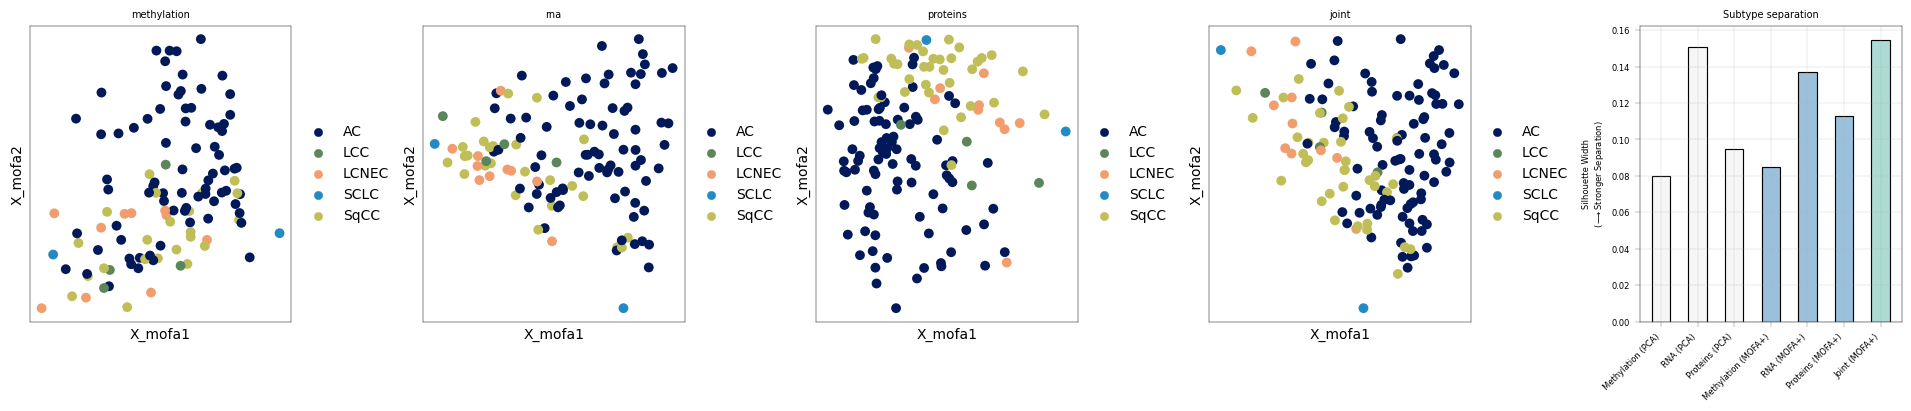

In [73]:
plot_kwargs = {
    "basis": "X_mofa",
    "color": "who2015_histology",
    "size": 200,
    "palette": apt.pl.BasePalettes().get("qualitative"),
    "show": False,
    "title": "",
}
modalities = {
    "methylation": methylation.copy(),
    "rna": rna.copy(),
    "proteins": proteins.copy(),
    "joint": multimodal.copy(),
}

fig, axm = apt.pl.create_figure(1, 5, figsize=(19, 4))

for idx, (modality, data) in enumerate(modalities.items()):
    muon.pl.embedding(data, ax=axm[idx], **plot_kwargs)
    apt.pl.label_axes(ax=axm[idx], title=modality)


apt.pl.barplot(
    ax=axm[4],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "RNA (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Proteins (PCA)": "#eeeeee",
        "Proteins (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[4],
    ylabel="Silhouette Width\n($\\longrightarrow$Stronger Separation)",
    title="Subtype separation",
)
plt.xticks(rotation=45, ha="right")
plt.show()

In [74]:
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}

In [75]:
from matplotlib.transforms import blended_transform_factory


def annotate_level1_groups(
    ax: plt.Axes,
    groups: list[tuple[str, float, float]],
    *,
    y: float = -0.6,
    pad: float = 0.4,
    label_gap: float = 0.05,
    tick_height: float = 0.0,
    linewidth: float = 1.0,
    color: str = "black",
    fontsize: int = 6,
    fontweight: str = "bold",
    bottom_margin: float | None = None,
) -> plt.Axes:
    """Annotate the level-1 grouping of a nested grouped bar plot.

    The level-2 bars (here the omics modalities) are drawn by alphapepttools; this
    function adds the enclosing level-1 indicator (here the embedding method) beneath the
    axis. Each level-1 group is marked by a horizontal line spanning its bars, with a
    centered label below it and optional bracket-style end ticks.

    The line uses a blended transform: x in data coordinates so it tracks the bar
    positions, and y in axes-fraction coordinates so the indicator stays a fixed distance
    below the axis irrespective of the plotted bar heights.

    Parameters
    ----------
    ax
        Axes holding the grouped bar plot. Bars are assumed to sit at integer x positions.
    groups
        One ``(label, x_start, x_end)`` tuple per level-1 group, where ``x_start`` and
        ``x_end`` are the data x-coordinates of the group's first and last bar.
    y
        Axes-fraction y-coordinate of the spanning line; negative values sit below the axis.
    pad
        Data-coordinate amount by which each spanning line extends past its end bars.
    label_gap
        Axes-fraction gap between the spanning line and the label drawn below it.
    tick_height
        Axes-fraction height of the bracket-style end ticks; set to ``0`` to omit them.
    linewidth
        Width of the spanning line and end ticks.
    color
        Color of the lines, ticks, and labels.
    fontweight
        Font weight of the level-1 labels.
    bottom_margin
        If given, reserve this figure-fraction bottom margin via ``subplots_adjust`` so the
        annotation is not clipped. Only needed when the figure neither uses constrained
        layout nor is saved with ``bbox_inches="tight"``; leave ``None`` otherwise.

    Returns
    -------
    The annotated axes, for chaining.
    """
    # x in data coordinates (tracks the bars), y in axes fraction (fixed below the axis).
    transform = blended_transform_factory(ax.transData, ax.transAxes)

    for label, x_start, x_end in groups:
        x0, x1 = x_start - pad, x_end + pad

        ax.plot([x0, x1], [y, y], transform=transform, color=color, linewidth=linewidth, clip_on=False)

        # End ticks point up toward the bars so each span reads as an enclosing bracket.
        if tick_height:
            for x_tick in (x0, x1):
                ax.plot([x_tick, x_tick], [y, y + tick_height], transform=transform, color=color, linewidth=linewidth, clip_on=False)

        ax.text((x0 + x1) / 2, y - label_gap, label, transform=transform, ha="center", va="top", color=color, fontsize=fontsize, fontweight=fontweight, clip_on=False)

    if bottom_margin is not None:
        # subplots_adjust conflicts with constrained layout, so drop the layout engine first.
        ax.figure.set_layout_engine("none")
        ax.figure.subplots_adjust(bottom=bottom_margin)

    return ax

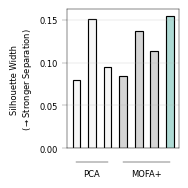

In [77]:
# Keep only the spine/axis styling that defaults.PlotSettings does not govern;
# font sizes and weights now follow the global rcParams derived from defaults.
# plot_params = {
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.linewidth": 1.0,
#     "axes.labelsize": "large",
#     "axes.labelweight": "bold",
# }

# with mpl.rc_context(plot_params):
fig, axm = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))

# Level 2 (the omics modalities) is drawn by alphapepttools, one bar per method.
apt.pl.barplot(
    ax=axm[0],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "Proteins (PCA)": "#eeeeee",
        "Methylation (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "RNA (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "Proteins (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[0],
    ylabel="Silhouette Width\n($\\rightarrow$Stronger Separation)",
    # title="Subtype separation",
)
plt.xticks([])
plt.yticks([0, 0.05, 0.10, 0.15])
# plt.xticks(range(7), ["Methylation", "RNA", "Proteins", "Methylation", "RNA", "Proteins", "Multimodal"], rotation=90, ha="center")
# plt.xticks(range(4), ["Methylation", "RNA", "Proteins", "Multimodal"], rotation=90, ha="center")

# Level 1 (the embedding method): PCA spans bars 0-2, MOFA+ spans bars 3-6.
annotate_level1_groups(axm[0], [("PCA", 0, 2), ("MOFA+", 3, 6)], fontweight="normal", pad=0., y=-0.1, linewidth=defaults.plot_settings.linewidths["medium"])


# bbox_inches="tight" keeps the level-1 annotation drawn below the axis from being clipped.
fig.savefig("../data/plots/cohort-separation.png", transparent=True, dpi=600, bbox_inches="tight")
plt.show()
